In [2]:
import pandas as pd 
import numpy as np

from scipy.stats import linregress, pearsonr

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))
system_variables

array(['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs',
       'CHabs', 'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs',
       'RIabs', 'pH', 'Lactate', 'Butyrate', 'Acetate', 'AcGum', 'ArGal',
       'Inulin', 'Pectin', 'Starch', 'Xylan'], dtype='<U8')

In [4]:
spColorDict = {'AC':(0,0,1),
  'BA':(1.0000,0,0),
  'BH':(0,1.0000,0),
  'BL':(1.0000,0.1034,0.7241),
  'BU':(1.0000,0.8276,0),
  'CA':(0,0.3448,0),
  'CC':(0.5172,0.5172,1.0000),
  'CH':(0.6207,0.3103,0.2759),
  'DF':(0,1.0000,0.7586),
  'EL':(0,0.5172,0.5862),
  'ER':(0,0,0.4828),
  'FP':(0.5862,0.8276,0.3103),
  'PC':(0.9655,0.6207,0.8621),
  'PJ':(0.8276,0.0690,1.0000),
  'RI':(0.4828,0.1034,0.4138)};

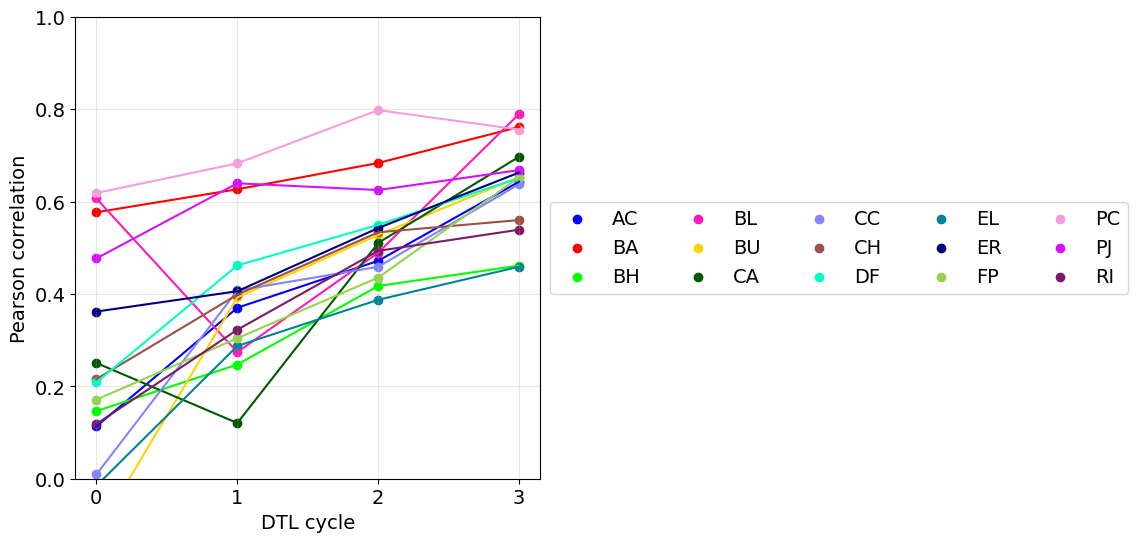

In [5]:
plt.figure(figsize=(6, 6))

for j, obs in enumerate(species):
    r_vals = []
    p_vals = []
    for i in range(4):
        k_fold_df = pd.read_csv(f"kfold/MiRNN_20_fold_32h_dtl_{i}.csv") 
        
        true_vals = []
        pred_vals = []
        stdv_vals = []
        
        for exp_name, kf_df in k_fold_df.groupby("Experiments"):
            true_vals_exp = kf_df[f'{obs} true'].values
            pred_vals_exp = kf_df[f'{obs} pred'].values 
            stdv_vals_exp = kf_df[f'{obs} stdv'].values 

            # if species was inoculated        
            if true_vals_exp[0] > 0:
                # if not nan
                for true_val_exp, pred_val_exp, stdv_val_exp in zip(true_vals_exp[1:], pred_vals_exp[1:], stdv_vals_exp[1:]):
                    if not np.isnan(true_val_exp):
                        true_vals.append(true_val_exp)
                        pred_vals.append(pred_val_exp)
                        stdv_vals.append(stdv_val_exp)

        true_vals = np.array(true_vals)
        pred_vals = np.array(pred_vals)
        stdv_vals = np.array(stdv_vals)
        
        r_val, p_val = pearsonr(true_vals, pred_vals)
        p_vals.append(p_val)
        r_vals.append(r_val)
        
    plt.plot(range(0, 4), r_vals, c=spColorDict[obs.split('abs')[0]])
    plt.scatter(range(0, 4), r_vals, label=obs.split('abs')[0], color=spColorDict[obs.split('abs')[0]])
    
plt.legend(loc='center left', ncol=5, bbox_to_anchor=(1, .5), fontsize=14)
plt.xticks(range(0, 4), fontsize=14)

plt.xlabel('DTL cycle', fontsize=14)
plt.ylabel('Pearson correlation', fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim([0, 1])

plt.grid(alpha=.3)

# plt.savefig("figures/improvement/species_improvement.svg", dpi=300)
plt.show()

In [8]:
# p values for DTL 3 
p_vals = []
k_fold_df = pd.read_csv(f"kfold/MiRNN_20_fold_32h_dtl_3.csv") 

for j, obs in enumerate(species):

    true_vals = []
    pred_vals = []
    stdv_vals = []

    for exp_name, kf_df in k_fold_df.groupby("Experiments"):
        true_vals_exp = kf_df[f'{obs} true'].values
        pred_vals_exp = kf_df[f'{obs} pred'].values 
        stdv_vals_exp = kf_df[f'{obs} stdv'].values 

        # if species was inoculated        
        if true_vals_exp[0] > 0:
            # if not nan
            for true_val_exp, pred_val_exp, stdv_val_exp in zip(true_vals_exp[1:], pred_vals_exp[1:], stdv_vals_exp[1:]):
                if not np.isnan(true_val_exp):
                    true_vals.append(true_val_exp)
                    pred_vals.append(pred_val_exp)
                    stdv_vals.append(stdv_val_exp)

    true_vals = np.array(true_vals)
    pred_vals = np.array(pred_vals)
    stdv_vals = np.array(stdv_vals)

    r_val, p_val = pearsonr(true_vals, pred_vals)
    p_vals.append(p_val)        

In [9]:
np.min(p_vals)

0.0

In [10]:
np.max(p_vals)

1.6627334209332935e-55

In [11]:
# log that ignores zeros
def zlog(x):
    x[x <= 0] = 1
    return np.log(x)

# shannon diversity
def shannon(y):
    y = np.clip(y, 0, np.inf)
    if np.nansum(y) > 0:
        y_rel = y / np.nansum(y)
        return np.nansum(-zlog(y_rel)*y_rel)
    else:
        return np.nan

# define objective 
def objective(y):
    
    # y is measured exp data [n_time, n_species + n_metabolites]

    # endpoint shannon diversity
    diversity = shannon(y[-1, :len(species)])

    # variance in species abundances in last two passages
    if np.any(np.isnan(y[-2:, :len(species)])):
        instability = np.nan
    else:
        species_stdv = np.std(y[-2:, :len(species)], 0)
        instability  = np.where(species_stdv>0, species_stdv, 0).mean() 

    # endpoint butyrate production 
    butyrate =  y[-1, -2]   

    return diversity, instability, butyrate

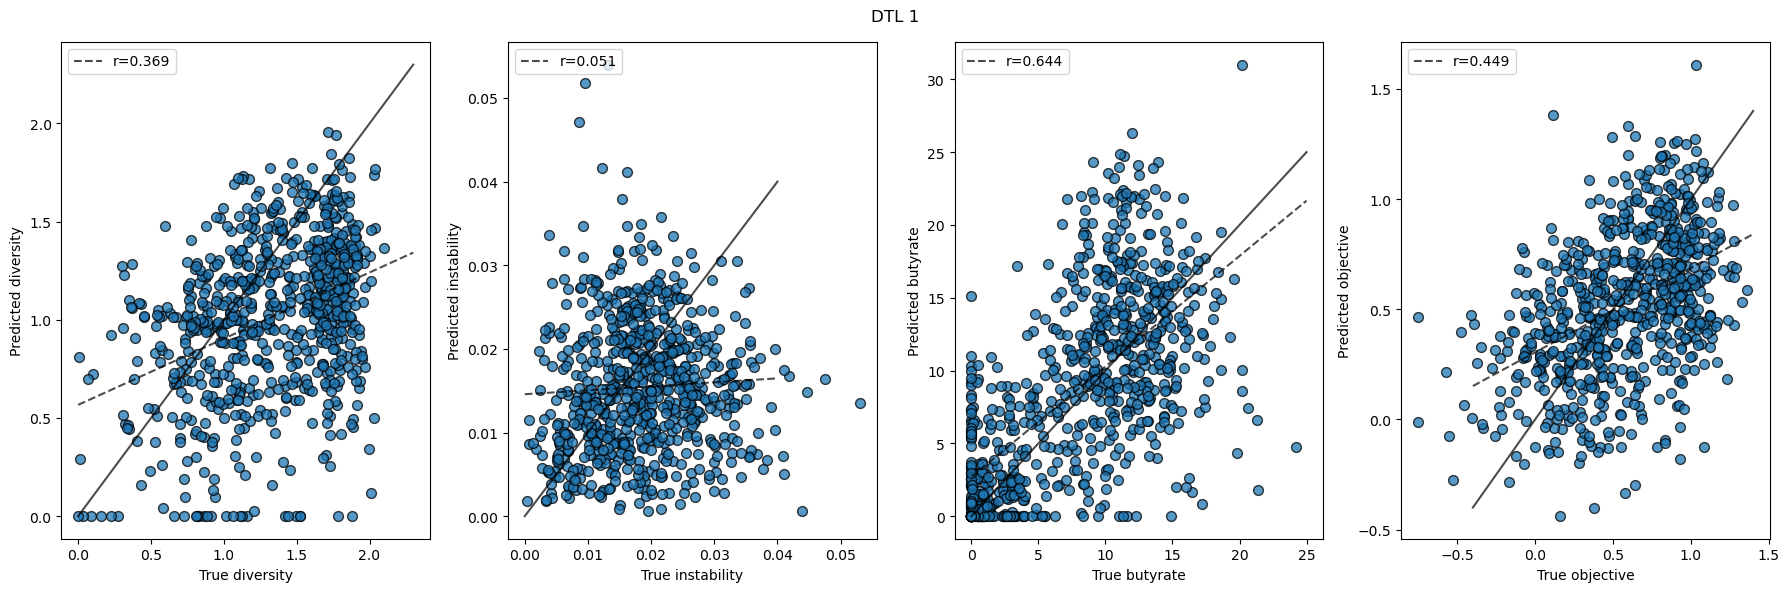

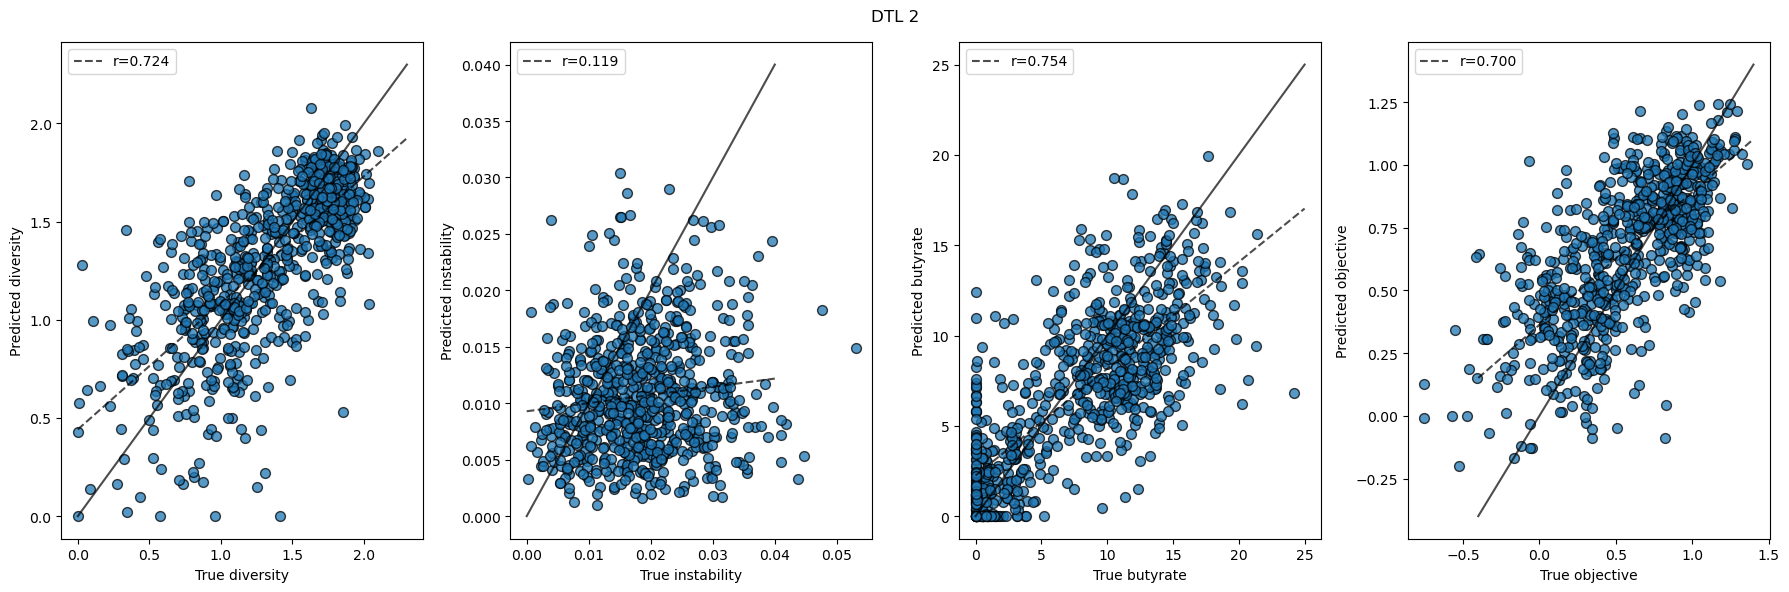

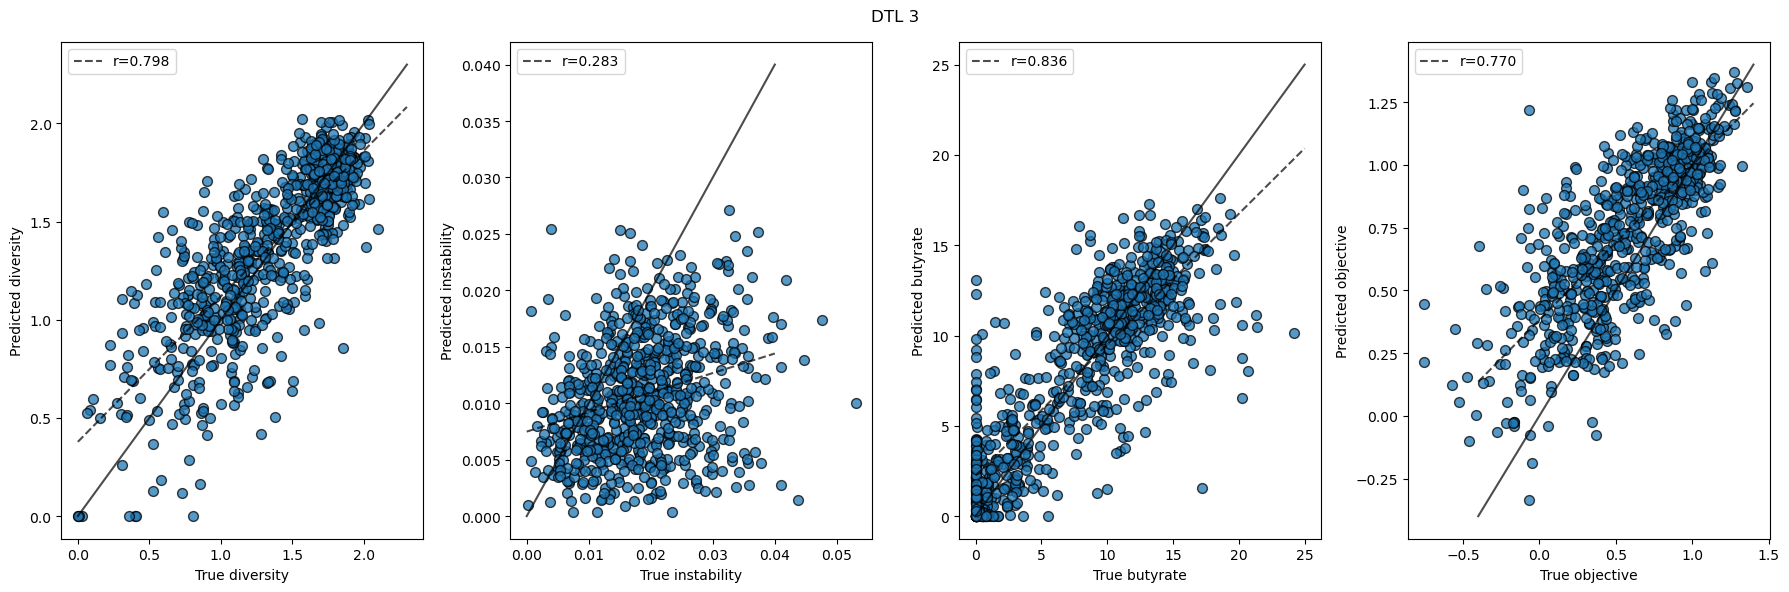

In [12]:
colors = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Teal
    "#9edae5",  # Light Blue
    "#c7c7c7",  # Light Gray
    "#c49c94",  # Light Red
    "#98df8a",  # Light Green
    "#f7b6d2"   # Light Pink
]

for i in range(1, 4):
    k_fold_df = pd.read_csv(f"kfold/MiRNN_20_fold_32h_dtl_{i}.csv") 

    diversity_true = []
    instability_true = []
    butyrate_true = []
    objective_true = []

    diversity_pred = []
    instability_pred = []
    butyrate_pred = []
    objective_pred = []

    for exp_name, kf_df in k_fold_df.groupby("Experiments"):

        # make sure df has 4 time points 
        if kf_df.shape[0] > 2:
        
            # true vals
            div_true, inst_true, bu_true = objective(kf_df[[f"{sys_var} true" for sys_var in species+metabolites]].values)

            # predicted vals
            div_pred, inst_pred, bu_pred = objective(kf_df[[f"{sys_var} pred" for sys_var in species+metabolites]].values)

            # save vals 
            diversity_true.append(div_true)
            diversity_pred.append(div_pred)
            instability_true.append(inst_true)
            instability_pred.append(inst_pred)
            butyrate_true.append(bu_true)
            butyrate_pred.append(bu_pred)

            objective_true.append(div_true/2.2569 + bu_true/24.206144 - inst_true/.05319)
            objective_pred.append(div_pred/2.2569 + bu_pred/24.206144 - inst_pred/.05319)

    diversity_true = np.array(diversity_true)
    instability_true = np.array(instability_true)
    butyrate_true = np.array(butyrate_true)
    objective_true = np.array(objective_true)

    diversity_pred = np.array(diversity_pred)
    instability_pred = np.array(instability_pred)
    butyrate_pred = np.array(butyrate_pred)
    objective_pred = np.array(objective_pred)

    # remove nans 
    div_nan = np.array([isnan_true or isnan_pred for isnan_true, isnan_pred in zip(np.isnan(diversity_true),
                                                                                   np.isnan(diversity_pred))])
    ins_nan = np.isnan(instability_true)
    but_nan = np.isnan(butyrate_true)
    obj_nan = np.array([isnan_true or isnan_pred for isnan_true, isnan_pred in zip(np.isnan(objective_true),
                                                                                   np.isnan(objective_pred))])
    
    diversity_true = diversity_true[~div_nan]
    diversity_pred = diversity_pred[~div_nan]
    
    instability_true = instability_true[~ins_nan]
    instability_pred = instability_pred[~ins_nan]
    
    butyrate_true = butyrate_true[~but_nan]
    butyrate_pred = butyrate_pred[~but_nan]
    
    objective_true = objective_true[~obj_nan]
    objective_pred = objective_pred[~obj_nan]
    
    plt.figure(figsize=(18, 6))
    plt.subplot(1,4,1)
    
    m, b, r, p, se = linregress(diversity_true, diversity_pred)
    x_line = np.linspace(0, 2.3)
    y_line = m*x_line + b
    plt.scatter(diversity_true, diversity_pred, s=50, edgecolor='k', alpha=.75)
    plt.plot(x_line, x_line, linestyle='-', color='k', alpha=.7, zorder=1)
    plt.plot(x_line, y_line, linestyle='--', color='k', alpha=.7, zorder=1, 
             label="r={:.3f}".format(r))
    plt.legend(loc='upper left')
    plt.xlabel("True diversity")
    plt.ylabel("Predicted diversity")

    plt.subplot(1,4,2)

    m, b, r, p, se = linregress(instability_true, instability_pred)
    x_line = np.linspace(0, .04)
    y_line = m*x_line + b
    plt.scatter(instability_true, instability_pred, s=50, edgecolor='k', alpha=.75)
    plt.plot(x_line, x_line, linestyle='-', color='k', alpha=.7, zorder=1)
    plt.plot(x_line, y_line, linestyle='--', color='k', alpha=.7, zorder=1, 
             label="r={:.3f}".format(r))
    plt.legend(loc='upper left')
    plt.xlabel("True instability")
    plt.ylabel("Predicted instability")

    plt.subplot(1,4,3)

    m, b, r, p, se = linregress(butyrate_true, butyrate_pred)
    x_line = np.linspace(0, 25)
    y_line = m*x_line + b
    plt.scatter(butyrate_true, butyrate_pred, s=50, edgecolor='k', alpha=.75)
    plt.plot(x_line, x_line, linestyle='-', color='k', alpha=.7, zorder=1)
    plt.plot(x_line, y_line, linestyle='--', color='k', alpha=.7, zorder=1, 
             label="r={:.3f}".format(r))
    plt.legend(loc='upper left')
    plt.xlabel("True butyrate")
    plt.ylabel("Predicted butyrate")

    plt.subplot(1,4,4)

    m, b, r, p, se = linregress(objective_true, objective_pred)
    x_line = np.linspace(-.4, 1.4)
    y_line = m*x_line + b
    plt.scatter(objective_true, objective_pred, s=50, edgecolor='k', alpha=.75)
    plt.plot(x_line, x_line, linestyle='-', color='k', alpha=.7, zorder=1)
    plt.plot(x_line, y_line, linestyle='--', color='k', alpha=.7, zorder=1, 
             label="r={:.3f}".format(r))
    plt.legend(loc='upper left')
    plt.xlabel("True objective")
    plt.ylabel("Predicted objective")

    plt.suptitle(f"DTL {i}")
    plt.tight_layout()
    plt.show()

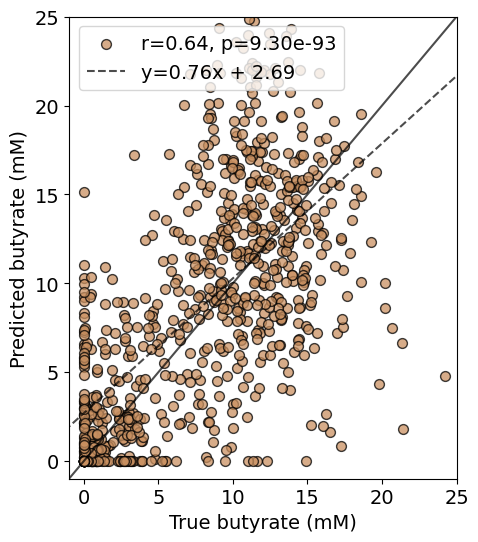

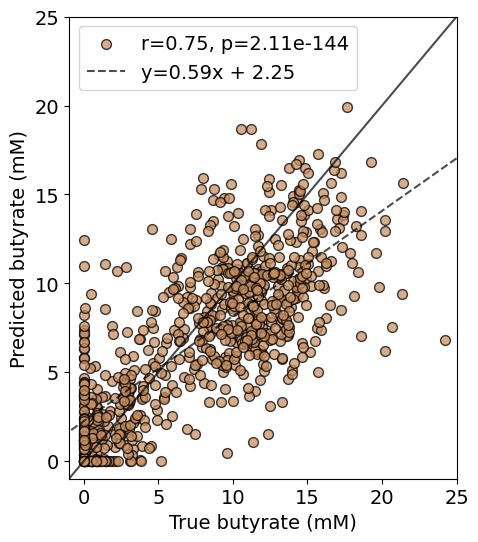

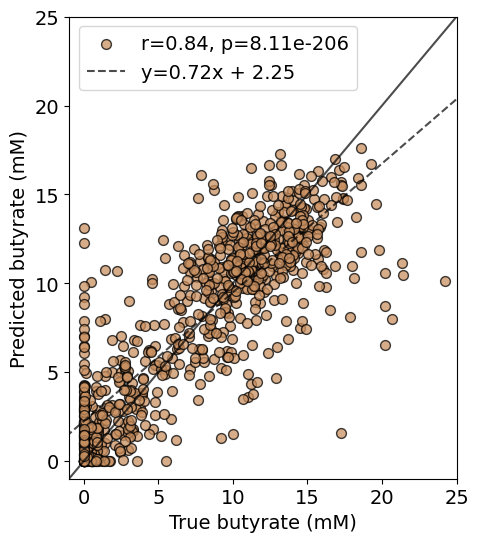

In [13]:
import seaborn as sns
sns.set_palette('colorblind')

for i in range(1, 4):
    k_fold_df = pd.read_csv(f"kfold/MiRNN_20_fold_32h_dtl_{i}.csv") 

    diversity_true = []
    instability_true = []
    butyrate_true = []
    objective_true = []

    diversity_pred = []
    instability_pred = []
    butyrate_pred = []
    objective_pred = []

    for exp_name, kf_df in k_fold_df.groupby("Experiments"):

        # make sure df has 4 time points 
        if kf_df.shape[0] > 2:
        
            # true vals
            div_true, inst_true, bu_true = objective(kf_df[[f"{sys_var} true" for sys_var in species+metabolites]].values)

            # predicted vals
            div_pred, inst_pred, bu_pred = objective(kf_df[[f"{sys_var} pred" for sys_var in species+metabolites]].values)

            # save vals 
            diversity_true.append(div_true)
            diversity_pred.append(div_pred)
            instability_true.append(inst_true)
            instability_pred.append(inst_pred)
            butyrate_true.append(bu_true)
            butyrate_pred.append(bu_pred)

            objective_true.append(div_true/2.2569 + bu_true/24.206144 - inst_true/.05319)
            objective_pred.append(div_pred/2.2569 + bu_pred/24.206144 - inst_pred/.05319)

    diversity_true = np.array(diversity_true)
    instability_true = np.array(instability_true)
    butyrate_true = np.array(butyrate_true)
    objective_true = np.array(objective_true)

    diversity_pred = np.array(diversity_pred)
    instability_pred = np.array(instability_pred)
    butyrate_pred = np.array(butyrate_pred)
    objective_pred = np.array(objective_pred)

    # remove nans 
    div_nan = np.array([isnan_true or isnan_pred for isnan_true, isnan_pred in zip(np.isnan(diversity_true),
                                                                                   np.isnan(diversity_pred))])
    ins_nan = np.isnan(instability_true)
    but_nan = np.isnan(butyrate_true)
    obj_nan = np.array([isnan_true or isnan_pred for isnan_true, isnan_pred in zip(np.isnan(objective_true),
                                                                                   np.isnan(objective_pred))])
    
    diversity_true = diversity_true[~div_nan]
    diversity_pred = diversity_pred[~div_nan]
    
    instability_true = instability_true[~ins_nan]
    instability_pred = instability_pred[~ins_nan]
    
    butyrate_true = butyrate_true[~but_nan]
    butyrate_pred = butyrate_pred[~but_nan]
    
    objective_true = objective_true[~obj_nan]
    objective_pred = objective_pred[~obj_nan]
    
    plt.figure(figsize=(5, 6))

    m, b, r, p, se = linregress(butyrate_true, butyrate_pred)
    x_line = np.linspace(-10, 30)
    y_line = m*x_line + b
    plt.scatter(butyrate_true, butyrate_pred, c='C5', s=50, edgecolor='k', alpha=.75,
                label="r={:.2f}, p={:.2e}".format(r, p))
    plt.plot(x_line, x_line, linestyle='-', color='k', alpha=.7, zorder=1)
    plt.plot(x_line, y_line, linestyle='--', color='k', alpha=.7, zorder=1, 
             label="y={:.2f}x + {:.2f}".format(m, b))
    plt.legend(loc='upper left', fontsize=14)
    plt.xlabel("True butyrate (mM)", fontsize=14)
    plt.ylabel("Predicted butyrate (mM)", fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim([-1, 25])
    plt.ylim([-1, 25])
    
    # plt.savefig(f"figures/improvement/butyrate_pred_dtl_{i}.svg", dpi=300)
    plt.show()

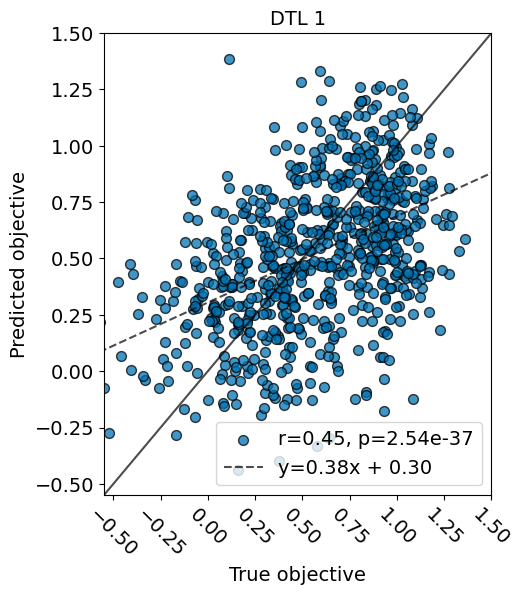

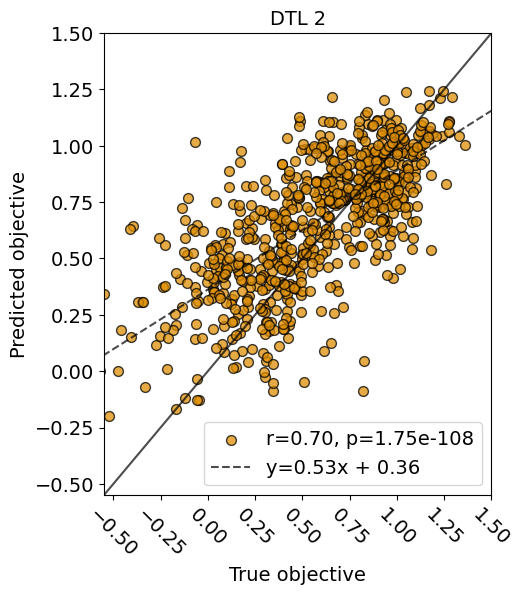

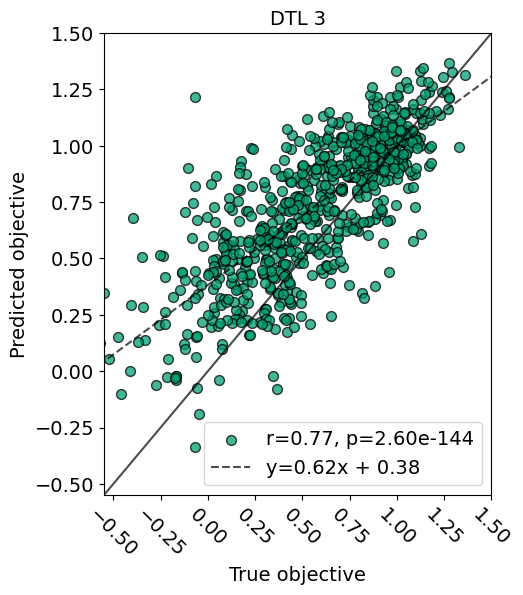

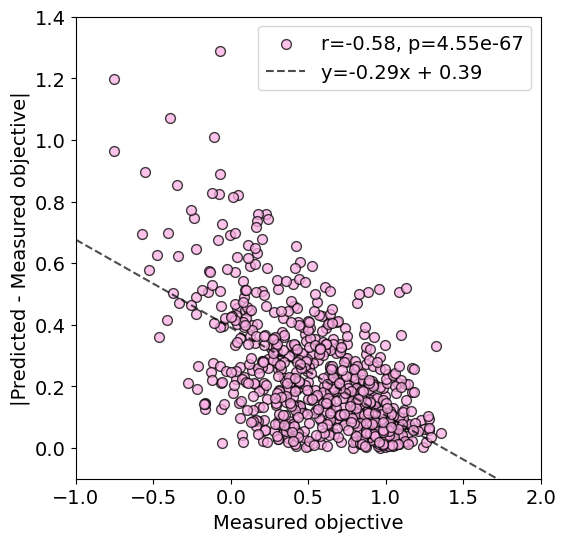

In [14]:
for i in range(1, 4):
    k_fold_df = pd.read_csv(f"kfold/MiRNN_20_fold_32h_dtl_{i}.csv") 

    diversity_true = []
    instability_true = []
    butyrate_true = []
    objective_true = []

    diversity_pred = []
    instability_pred = []
    butyrate_pred = []
    objective_pred = []

    for exp_name, kf_df in k_fold_df.groupby("Experiments"):

        # make sure df has 4 time points 
        if kf_df.shape[0] > 2:
        
            # true vals
            div_true, inst_true, bu_true = objective(kf_df[[f"{sys_var} true" for sys_var in species+metabolites]].values)

            # predicted vals
            div_pred, inst_pred, bu_pred = objective(kf_df[[f"{sys_var} pred" for sys_var in species+metabolites]].values)

            # save vals 
            diversity_true.append(div_true)
            diversity_pred.append(div_pred)
            instability_true.append(inst_true)
            instability_pred.append(inst_pred)
            butyrate_true.append(bu_true)
            butyrate_pred.append(bu_pred)

            objective_true.append(div_true/2.2569 + bu_true/24.206144 - inst_true/.05319)
            objective_pred.append(div_pred/2.2569 + bu_pred/24.206144 - inst_pred/.05319)

    diversity_true = np.array(diversity_true)
    instability_true = np.array(instability_true)
    butyrate_true = np.array(butyrate_true)
    objective_true = np.array(objective_true)

    diversity_pred = np.array(diversity_pred)
    instability_pred = np.array(instability_pred)
    butyrate_pred = np.array(butyrate_pred)
    objective_pred = np.array(objective_pred)

    # remove nans 
    div_nan = np.array([isnan_true or isnan_pred for isnan_true, isnan_pred in zip(np.isnan(diversity_true),
                                                                                   np.isnan(diversity_pred))])
    ins_nan = np.isnan(instability_true)
    but_nan = np.isnan(butyrate_true)
    obj_nan = np.array([isnan_true or isnan_pred for isnan_true, isnan_pred in zip(np.isnan(objective_true),
                                                                                   np.isnan(objective_pred))])
    
    diversity_true = diversity_true[~div_nan]
    diversity_pred = diversity_pred[~div_nan]
    
    instability_true = instability_true[~ins_nan]
    instability_pred = instability_pred[~ins_nan]
    
    butyrate_true = butyrate_true[~but_nan]
    butyrate_pred = butyrate_pred[~but_nan]
    
    objective_true = objective_true[~obj_nan]
    objective_pred = objective_pred[~obj_nan]
    
    plt.figure(figsize=(5, 6))

    m, b, r, p, se = linregress(objective_true, objective_pred)
    x_line = np.linspace(-1., 2.)
    y_line = m*x_line + b
    plt.scatter(objective_true, objective_pred, c=f'C{i-1}', s=50, edgecolor='k', alpha=.75,
                label="r={:.2f}, p={:.2e}".format(r, p))
    plt.plot(x_line, x_line, linestyle='-', color='k', alpha=.7, zorder=1)
    plt.plot(x_line, y_line, linestyle='--', color='k', alpha=.7, zorder=1, 
             label="y={:.2f}x + {:.2f}".format(m, b))
    plt.legend(loc='lower right',fontsize=14)
    plt.xlabel("True objective",fontsize=14)
    plt.ylabel("Predicted objective",fontsize=14)

    plt.xticks(fontsize=14, rotation=-45)
    plt.yticks(fontsize=14)
    
    plt.xlim([-.55, 1.5])
    plt.ylim([-.55, 1.5])
    
    plt.title(f"DTL {i}", fontsize=14)
    # plt.savefig(f"figures/improvement/objective_pred_dtl_{i}.svg", dpi=300)
    plt.show()
    
# prediction error 
obj_error = abs(objective_pred-objective_true)
plt.figure(figsize=(6, 6))
m, b, r, p, se = linregress(objective_true, obj_error)
x_line = np.linspace(-2, 2)
y_line = m*x_line + b
plt.scatter(objective_true, obj_error, c='C6', s=50, edgecolor='k', alpha=.75,
            label="r={:.2f}, p={:.2e}".format(r, p))
# plt.plot(x_line, x_line, linestyle='-', color='k', alpha=.7, zorder=1)
plt.plot(x_line, y_line, linestyle='--', color='k', alpha=.7, zorder=1, 
         label="y={:.2f}x + {:.2f}".format(m, b))
plt.legend(loc='upper right', fontsize=14)
plt.xlabel("Measured objective", fontsize=14)
plt.ylabel("|Predicted - Measured objective|", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim([-1, 2])
plt.ylim([-.1, 1.4])
# plt.savefig(f"figures/improvement/objective_pred_dtl_{i}_error.svg", dpi=300)
plt.show()

Butyrate 1 0.6438524235779233
Butyrate 2 0.7538149634409361
Butyrate 3 0.8363434563949556
Acetate 1 0.409628463001652
Acetate 2 0.506668725773818
Acetate 3 0.6559910585987623
Lactate 1 0.7078164726634725
Lactate 2 0.7817750194737655
Lactate 3 0.8145561747186851


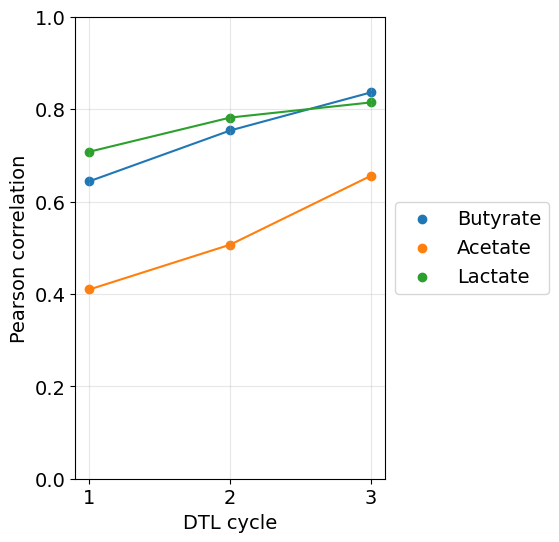

In [16]:
colors = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17becf",  # Teal
    "#9edae5",  # Light Blue
    "#c7c7c7",  # Light Gray
    "#c49c94",  # Light Red
    "#98df8a",  # Light Green
    "#f7b6d2"   # Light Pink
]

plt.figure(figsize=(4, 6))

for j, obs in enumerate(['Butyrate', 'Acetate', 'Lactate']):
    r_vals = []
    for i in range(1, 4):
        k_fold_df = pd.read_csv(f"kfold/MiRNN_20_fold_32h_dtl_{i}.csv") 
        
        true_vals = []
        pred_vals = []
        stdv_vals = []
        
        for exp_name, kf_df in k_fold_df.groupby("Experiments"):
            true_vals_exp = kf_df[f'{obs} true'].values
            pred_vals_exp = kf_df[f'{obs} pred'].values 
            stdv_vals_exp = kf_df[f'{obs} stdv'].values 

            # if not nan
            for true_val_exp, pred_val_exp, stdv_val_exp in zip(true_vals_exp[-1:], pred_vals_exp[-1:], stdv_vals_exp[-1:]):
                if not np.isnan(true_val_exp):
                    true_vals.append(true_val_exp)
                    pred_vals.append(pred_val_exp)
                    stdv_vals.append(stdv_val_exp)

        true_vals = np.array(true_vals)
        pred_vals = np.array(pred_vals)
        stdv_vals = np.array(stdv_vals)
        
        r_vals.append(pearsonr(true_vals, pred_vals)[0])
        
        print(obs, i, r_vals[-1])
        
    plt.plot(range(1, 4), r_vals, c=colors[j])
    plt.scatter(range(1, 4), r_vals, label=obs.split('abs')[0], c=colors[j])
    
plt.legend(loc='center left', ncol=1, bbox_to_anchor=(1, .5), fontsize=14)
plt.xticks(range(1, 4))
plt.ylim([0, 1])

plt.xlabel('DTL cycle', fontsize=14)
plt.ylabel('Pearson correlation', fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=.3)

# plt.savefig("figures/improvement/metabolites_improvement.svg", dpi=300)
plt.show()